In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd


In [46]:
# Load data from file
df = pd.read_csv('tensile_data.csv')
display(df.head()) 

# Drop column no. from the data
df = df.drop(columns=["no."])
display(df[:10])


,no.,width_mm,thickness_mm,avg_area_mm2,max_force_N,tensile_break_Mpa,elongation_at_break,modulus_Mpa,tensile_strength,material_type
0,1,10.0,0.682,6.82,50.76,6.940,573.4,94.4,7.443,PLA
1,2,10.0,0.687,6.87,44.50,5.485,545.1,95.4,6.477,PLA
2,3,10.0,0.710,7.10,44.25,6.193,531.4,87.6,6.232,PLA
3,4,10.0,0.687,6.87,39.05,5.485,545.1,73.6,5.684,PLA
4,5,10.0,0.672,6.72,39.09,5.730,550.4,78.2,5.817,PLA


,width_mm,thickness_mm,avg_area_mm2,max_force_N,tensile_break_Mpa,elongation_at_break,modulus_Mpa,tensile_strength,material_type
0,10.0,0.682,6.82,50.76,6.940,573.4,94.4,7.443,PLA
1,10.0,0.687,6.87,44.50,5.485,545.1,95.4,6.477,PLA
2,10.0,0.710,7.10,44.25,6.193,531.4,87.6,6.232,PLA
3,10.0,0.687,6.87,39.05,5.485,545.1,73.6,5.684,PLA
4,10.0,0.672,6.72,39.09,5.730,550.4,78.2,5.817,PLA
5,10.0,0.563,5.63,36.37,NaN,548.7,123.0,6.460,PLA-CNC 1wt%
6,10.0,0.553,5.53,35.34,NaN,503.1,145.0,6.391,PLA-CNC 1wt%
7,10.0,0.536,5.36,35.38,NaN,472.7,112.0,6.601,PLA-CNC 1wt%
8,10.0,0.524,5.24,43.18,NaN,425.4,186.0,8.240,PLA-CNC 1wt%
9,10.0,0.664,6.64,41.57,NaN,462.7,109.0,6.261,PLA-CNC 1wt%


# Simple 1D FEM (axial bar under tension)
## Basic bar element under axial load

In [ ]:
# Parameters for FEM
L = 0.1  # 100 mm in meters

for idx, row in df.iterrows():
      print(f"\n===== Specimen {idx + 1} ({row['material_type']}) =====")

      A = row['avg_area'] * 1e-6     # Convert mm² to m²
      E = row['modulus_Mpa'] * 1e6  # Convert MPa to Pa
      F = row['max_force_N']       # N

      # Element stiffness matrix for axial bar element (2 nodes)
      k = (E * A / L) * np.array([[1, -1],
                              [-1, 1]])

      # Force vector: apply tensile force at node 2, node 1 fixed
      F_vec = np.array([0, F])

      # Boundary conditions: displacement at node 1 = 0 (fixed)
      # Reduce system by removing row/column of fixed DOF
      k_reduced = k[1:, 1:]
      F_reduced = F_vec[1:]

      # Solve for displacement at node 2
      u = np.linalg.solve(k_reduced, F_reduced)

      print(f"Displacement at free node: {u[0]*1000:.6f} mm")  # convert to mm
      print(f'This means the free end of the bar (the node where the force is applied) moves (elongates) by {u[0]*1000:.6f} millimeters under the applied tensile load.')

      # Calculate stress (force / area)
      stress = F / A / 1e6  # Convert Pa to MPa
      print(f"Axial stress in bar: {stress:.2f} MPa")
      print(f'This indicates the calculated stress in the bar is {stress:.2f} MPa')



===== Specimen 1 (PLA) =====
Displacement at free node: 7.884338 mm
This means the free end of the bar (the node where the force is applied) moves (elongates) by 7.884338 millimeters under the applied tensile load.
Axial stress in bar: 7.44 MPa
This indicates the calculated stress in the bar is 7.44 MPa

===== Specimen 2 (PLA) =====
Displacement at free node: 6.789767 mm
This means the free end of the bar (the node where the force is applied) moves (elongates) by 6.789767 millimeters under the applied tensile load.
Axial stress in bar: 6.48 MPa
This indicates the calculated stress in the bar is 6.48 MPa

===== Specimen 3 (PLA) =====
Displacement at free node: 7.114605 mm
This means the free end of the bar (the node where the force is applied) moves (elongates) by 7.114605 millimeters under the applied tensile load.
Axial stress in bar: 6.23 MPa
This indicates the calculated stress in the bar is 6.23 MPa

===== Specimen 4 (PLA) =====
Displacement at free node: 7.723008 mm
This means th

# 2D linear elasticity FEM simulation
## Option 1: Use FEniCS for FEM
2D rectangular  

In [ ]:
import dolfin as dfn # pip install fenics
import pandas as pd
import numpy as np

# Select only PLA as example data
df_data = pd.DataFrame(df[:5])

# Poisson's ratio (assumed)
nu = 0.35

# Assumed specimen length
length = 0.1  # in meters (100 mm)

# Mesh density
nx, ny = 20, 5

max_displacements = []
max_stresses = []
for idx, row in df_data.iterrows():
    print(f"\n===== Specimen {idx + 1} ({row['material_type']}) =====")
    
    # Convert dimensions
    width = row['width_mm'] / 1000     # to m
    thickness = row['thickness_mm'] / 1000  # to m
    A = row['avg_area'] * 1e-6         # m^2
    E = row['modulus_Mpa'] * 1e6       # convert Young's modulus to Pa
    F = row['max_force_N']             # N

    # Build 2D rectangular mesh (length x thickness)
    mesh = dfn.RectangleMesh(dfn.Point(0, 0), dfn.Point(length, thickness), nx, ny)

    # Function space
    V = dfn.VectorFunctionSpace(mesh, "Lagrange", degree=1)

    # Define boundaries
    def left_boundary(x, on_boundary):
        return on_boundary and dfn.near(x[0], 0)
    
    bc = dfn.DirichletBC(V, dfn.Constant((0.0, 0.0)), left_boundary)

    # Lame parameters
    mu = E / (2*(1 + nu))
    lmbda = E * nu / ((1 + nu)*(1 - 2*nu))

    # Strain and stress definitions
    def epsilon(u):
        return dfn.sym(dfn.grad(u))

    def sigma(u):
        return lmbda * dfn.tr(epsilon(u)) * dfn.Identity(2) + 2*mu * epsilon(u)

    # Variational problem
    u = dfn.TrialFunction(V)
    v = dfn.TestFunction(V)
    f_body = dfn.Constant((0, 0))

    a = dfn.inner(sigma(u), epsilon(v)) * dfn.dx
    L_form = dfn.dot(f_body, v) * dfn.dx

    # Traction on right boundary
    class RightBoundary(dfn.SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and dfn.near(x[0], length)

    right_boundary = RightBoundary()
    boundary_markers = dfn.MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)
    right_boundary.mark(boundary_markers, 1)
    ds = dfn.Measure("ds", domain=mesh, subdomain_data=boundary_markers)

    # Compute traction (force/area)
    cross_section_area = width * thickness
    traction_magnitude = F / cross_section_area
    T = dfn.Constant((traction_magnitude, 0))

    L_form += dfn.dot(T, v) * ds(1)

    # Solve
    u_sol = dfn.Function(V)
    dfn.solve(a == L_form, u_sol, bc)

    # Post-processing
    displacement_magnitude = dfn.sqrt(dfn.dot(u_sol, u_sol))
    max_disp = u_sol.vector().norm("linf") * 1000  # convert m to mm

    s = sigma(u_sol) - (1./3)*dfn.tr(sigma(u_sol)) * dfn.Identity(2)
    von_Mises = dfn.sqrt(3./2 * dfn.inner(s, s))

    V_scalar = dfn.FunctionSpace(mesh, "Lagrange", 1)
    von_Mises_proj = dfn.project(von_Mises, V_scalar)

    max_vm_stress = von_Mises_proj.vector().max() / 1e6  # Pa to MPa

    # Print results
    print(f"Max displacement: {max_disp:.6f} mm")
    print(f"Max von Mises stress: {max_vm_stress:.2f} MPa")

    # Save results for plotting
    max_displacements.append(max_disp)
    max_stresses.append(max_vm_stress)

    # # Optional: save to files
    # dfn.File(f"specimen_{idx+1}_displacement.pvd") << u_sol
    # dfn.File(f"specimen_{idx+1}_von_mises.pvd") << von_Mises_proj




===== Specimen 1 (PLA) =====
Max displacement: 6.860142 mm
Max von Mises stress: 6.91 MPa

===== Specimen 2 (PLA) =====
Max displacement: 5.907773 mm
Max von Mises stress: 6.01 MPa

===== Specimen 3 (PLA) =====
Max displacement: 6.190484 mm
Max von Mises stress: 5.79 MPa

===== Specimen 4 (PLA) =====
Max displacement: 6.719785 mm
Max von Mises stress: 5.28 MPa

===== Specimen 5 (PLA) =====
Max displacement: 6.472253 mm
Max von Mises stress: 5.40 MPa
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.


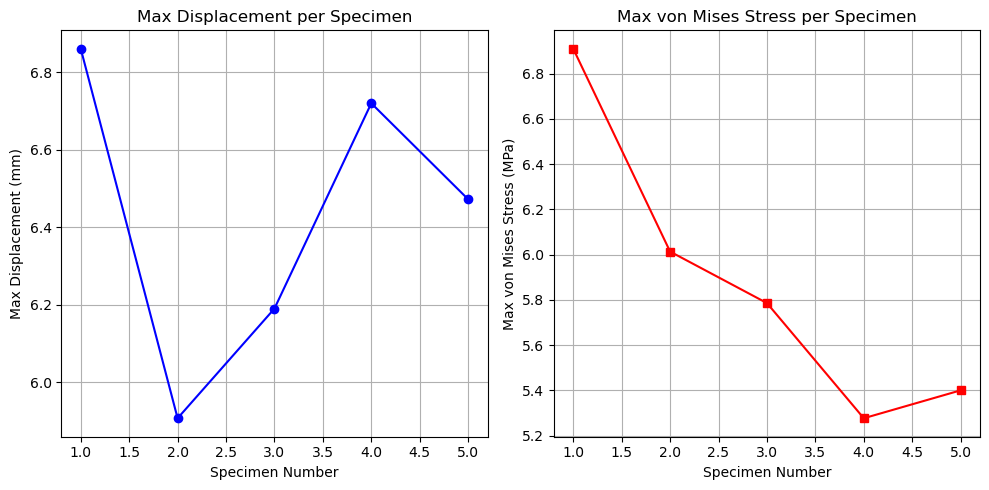

In [11]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(max_displacements)+1), max_displacements, marker='o', color='blue')
plt.xlabel('Specimen Number')
plt.ylabel('Max Displacement (mm)')
plt.title('Max Displacement per Specimen')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(max_stresses)+1), max_stresses, marker='s', color='red')
plt.xlabel('Specimen Number')
plt.ylabel('Max von Mises Stress (MPa)')
plt.title('Max von Mises Stress per Specimen')
plt.grid(True)

plt.tight_layout()
plt.show()

## Option 2: Use SfePy 

['Mesh', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_get_extension_side', '_spread_along_axis', 'absolute_import', 'assert_', 'cycle', 'elems_q2t', 'ensure_path', 'gen_block_mesh', 'gen_cylinder_mesh', 'gen_extended_block_mesh', 'gen_mesh_from_geom', 'gen_mesh_from_string', 'gen_mesh_from_voxels', 'gen_misc_mesh', 'gen_tiled_mesh', 'get_tensor_product_conn', 'main', 'nm', 'output', 'print_function', 'range', 'sys', 'tiled_mesh1d']

===== Specimen 1 (PLA) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


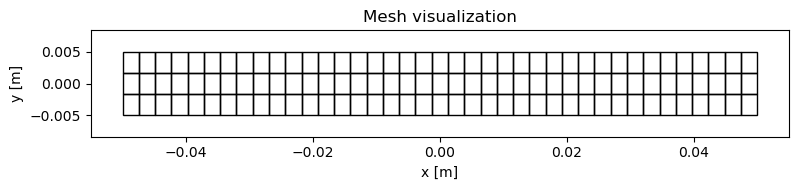

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 2.157820e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.366599e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.569626e-10 (rel: 7.274132e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


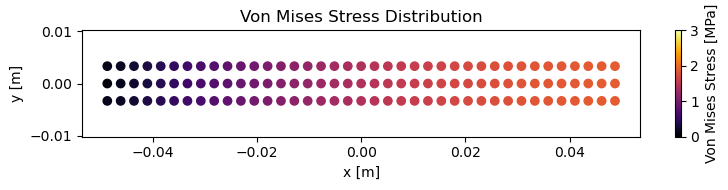


===== Specimen 2 (PLA) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


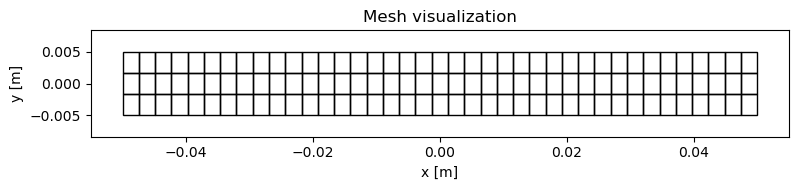

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 2.180678e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.402927e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.655334e-10 (rel: 7.590913e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


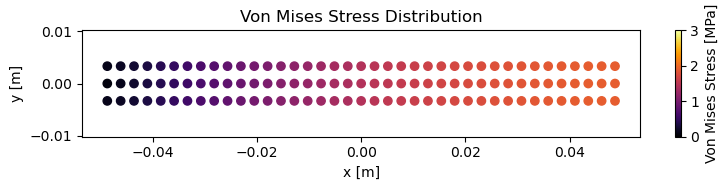


===== Specimen 3 (PLA) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


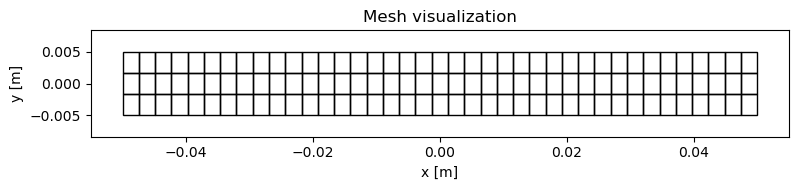

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 2.002383e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.427854e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.473237e-10 (rel: 7.357419e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


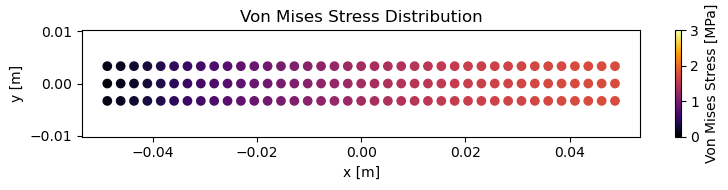


===== Specimen 4 (PLA) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


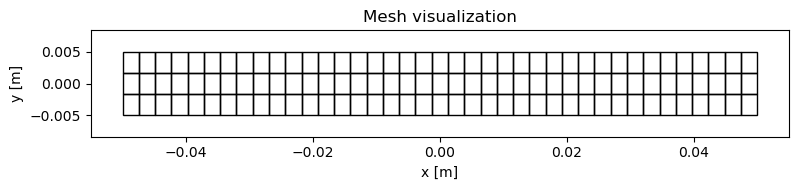

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 1.682368e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.143015e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.487363e-10 (rel: 8.840889e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


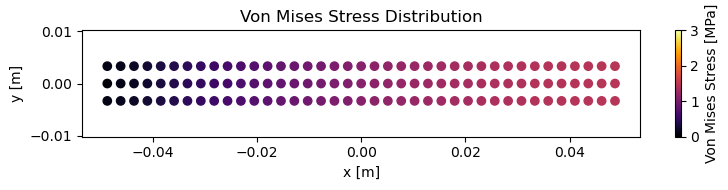


===== Specimen 5 (PLA) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


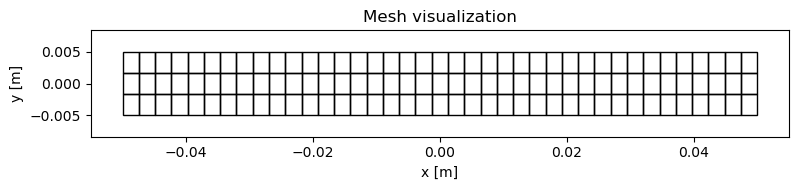

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 1.787516e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.148743e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.737756e-10 (rel: 9.721627e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


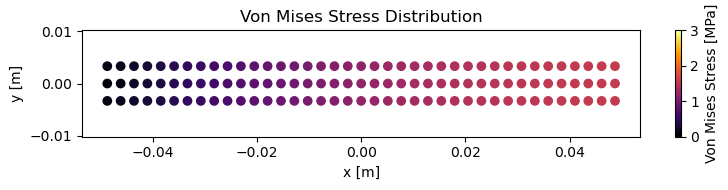


===== Specimen 6 (PLA-CNC 1wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


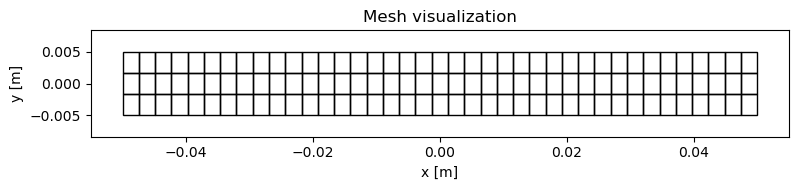

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 2.811566e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.539193e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.409776e-10 (rel: 5.014203e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


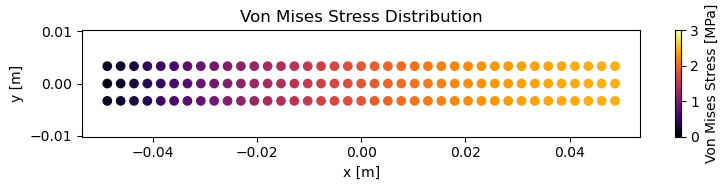


===== Specimen 7 (PLA-CNC 1wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


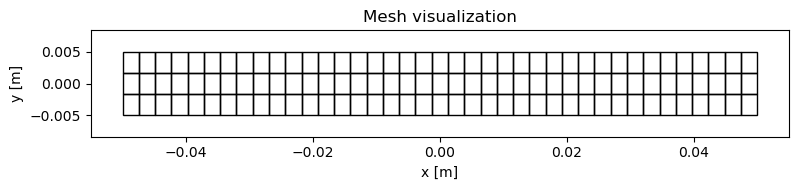

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 3.314448e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.902933e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 2.464312e-10 (rel: 7.435060e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.01 seconds
Max displacement magnitude: 0.001000 m


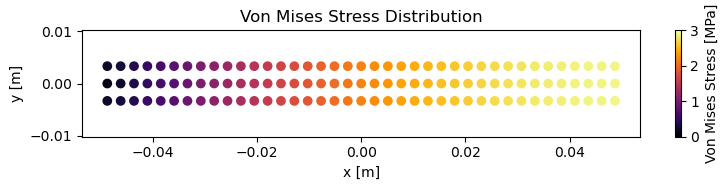


===== Specimen 8 (PLA-CNC 1wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


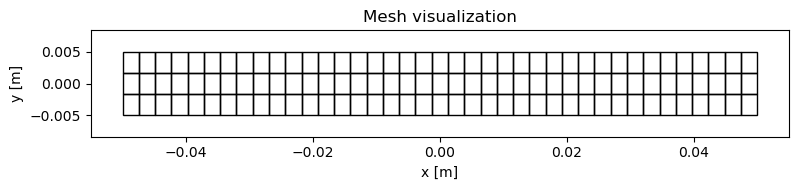

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 2.560125e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.632233e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.787596e-10 (rel: 6.982455e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


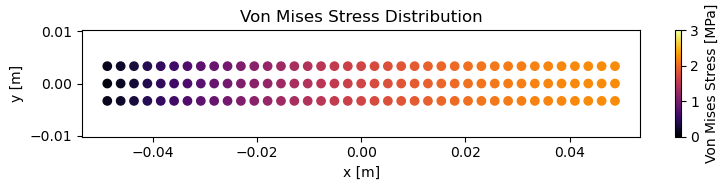


===== Specimen 9 (PLA-CNC 1wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


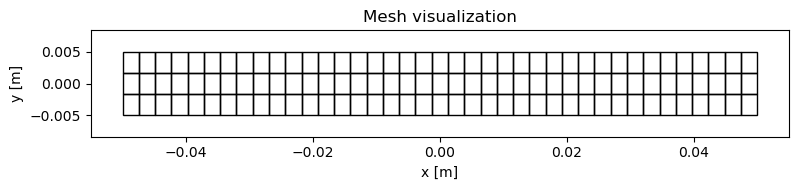

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 4.251636e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 2.775465e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 3.217710e-10 (rel: 7.568170e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


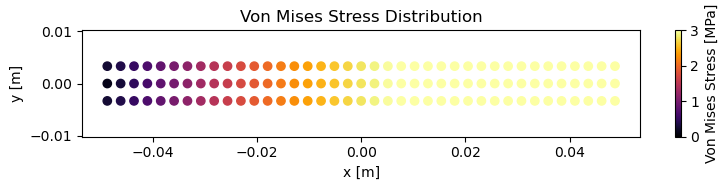


===== Specimen 10 (PLA-CNC 1wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


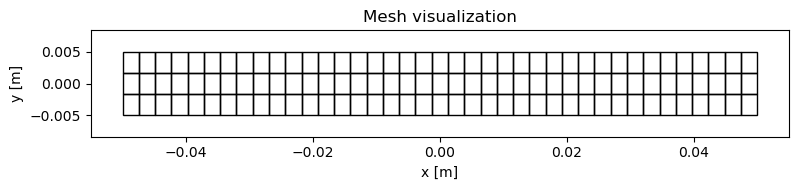

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 2.491550e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.401218e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.795929e-10 (rel: 7.208079e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


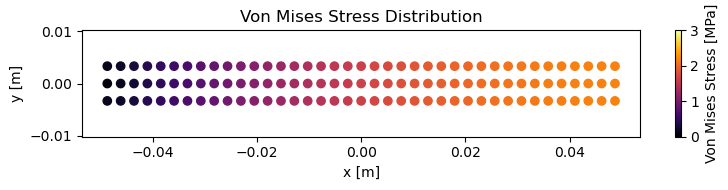


===== Specimen 11 (PLA-CNC 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


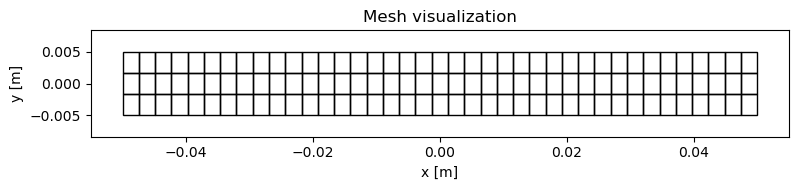

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 1.862948e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.518820e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.582297e-10 (rel: 8.493511e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


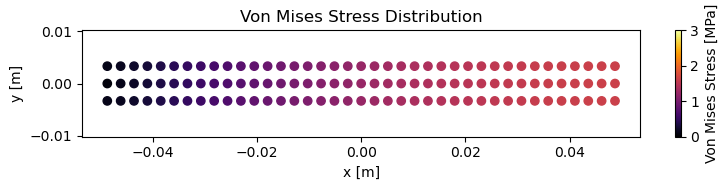


===== Specimen 12 (PLA-CNC 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


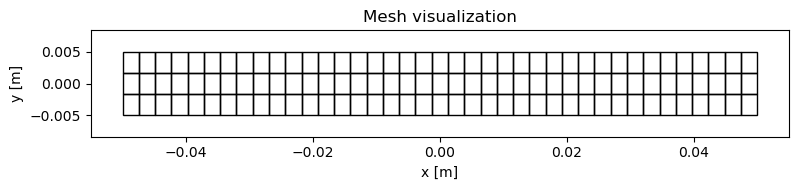

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 1.942952e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.359429e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.648903e-10 (rel: 8.486587e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


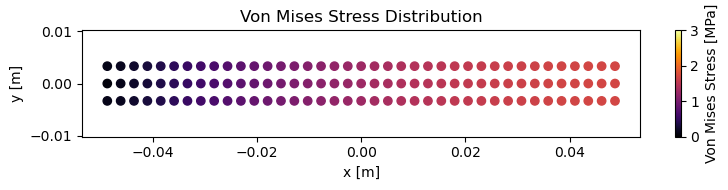


===== Specimen 13 (PLA-CNC 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


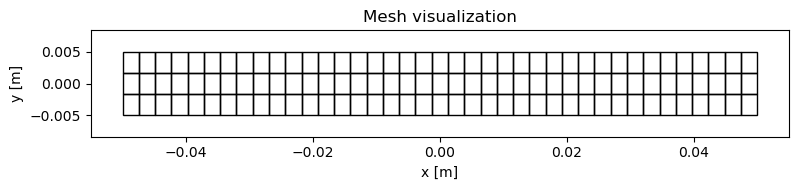

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 2.048100e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.429522e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.660613e-10 (rel: 8.108068e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.01 seconds
Max displacement magnitude: 0.001000 m


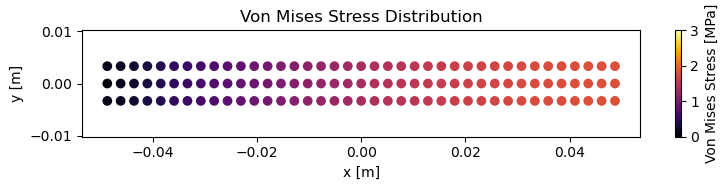


===== Specimen 14 (PLA-CNC 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


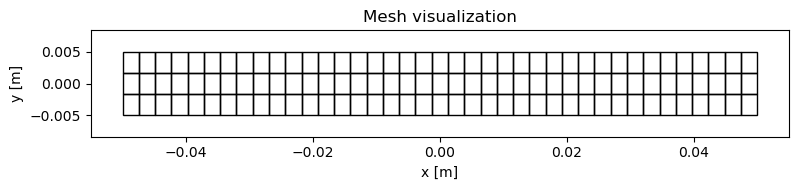

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 2.400117e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.588028e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 2.125553e-10 (rel: 8.856037e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


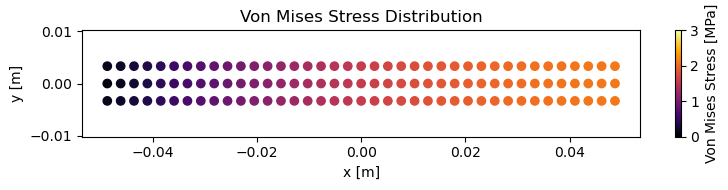


===== Specimen 15 (PLA-CNC 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


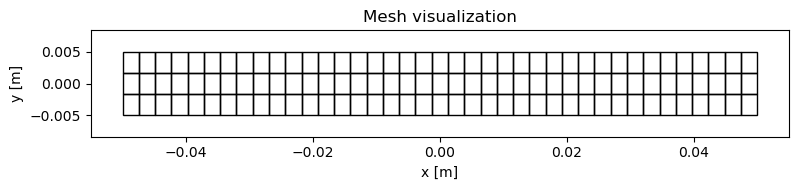

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 2.742991e+05 (rel: 1.000000e+00)
sfepy: warning: linear system solution precision is lower then the value set in solver options! (err = 1.579420e-10 < 1.000000e-10)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 2.029737e-10 (rel: 7.399723e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


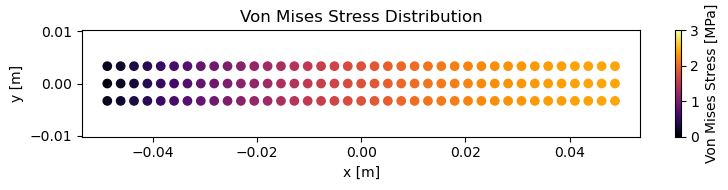


===== Specimen 16 (PLA-CNC-g-PLLA 1wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


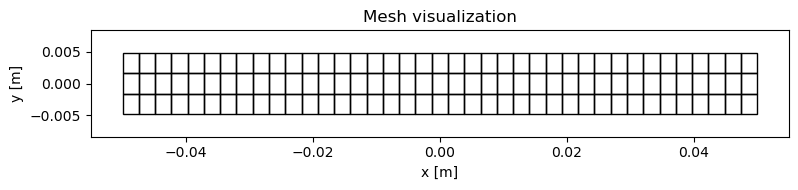

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 5.038314e+04 (rel: 1.000000e+00)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 4.546556e-11 (rel: 9.023963e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


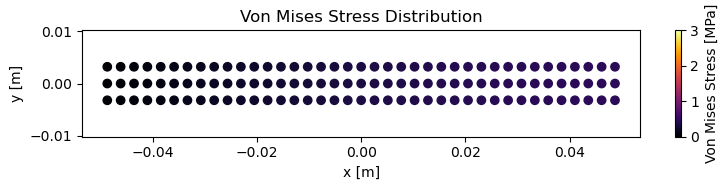


===== Specimen 17 (PLA-CNC-g-PLLA 1wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


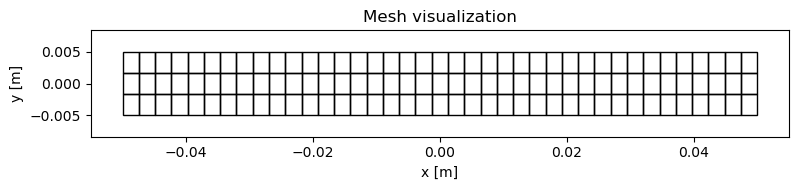

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 5.609008e+04 (rel: 1.000000e+00)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 3.960302e-11 (rel: 7.060610e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


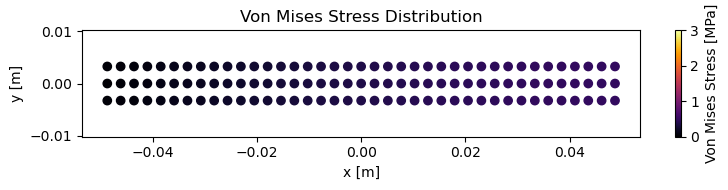


===== Specimen 18 (PLA-CNC-g-PLLA 1wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


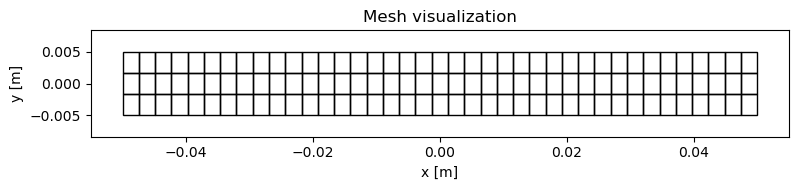

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 5.691707e+04 (rel: 1.000000e+00)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 5.806871e-11 (rel: 1.020234e-15)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


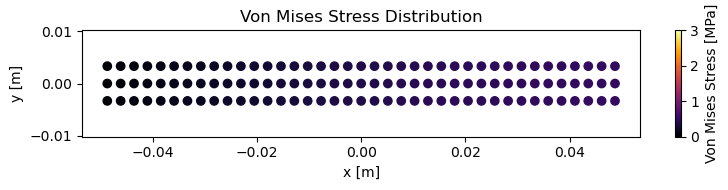


===== Specimen 19 (PLA-CNC-g-PLLA 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


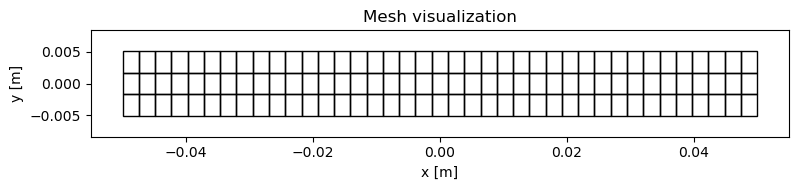

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 4.600357e+04 (rel: 1.000000e+00)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 3.686110e-11 (rel: 8.012662e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


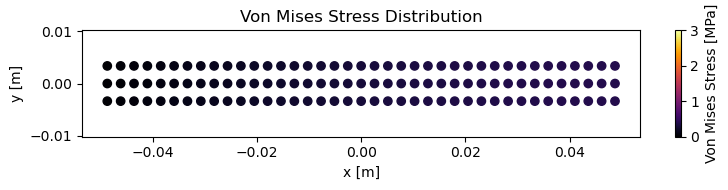


===== Specimen 20 (PLA-CNC-g-PLLA 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


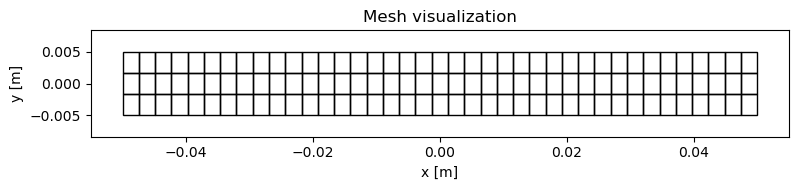

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 7.392926e+04 (rel: 1.000000e+00)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 6.296349e-11 (rel: 8.516721e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


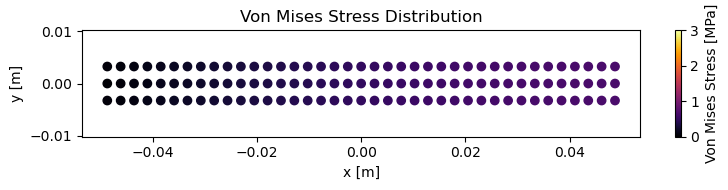


===== Specimen 21 (PLA-CNC-g-PLLA 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


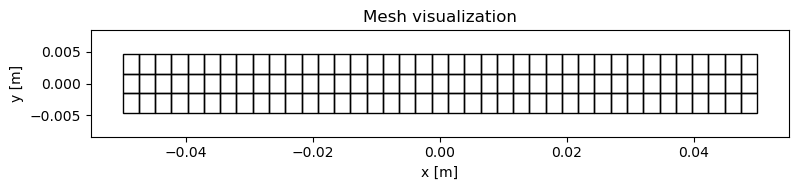

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 7.747327e+04 (rel: 1.000000e+00)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 5.247960e-11 (rel: 6.773897e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


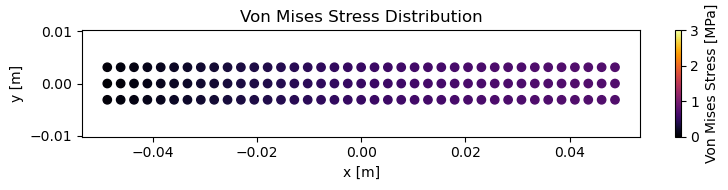


===== Specimen 22 (PLA-CNC-g-PLLA 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


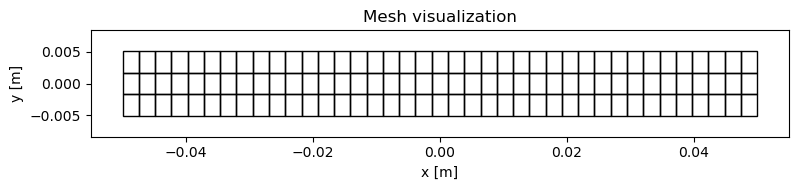

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 1.058536e+05 (rel: 1.000000e+00)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 9.665349e-11 (rel: 9.130863e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


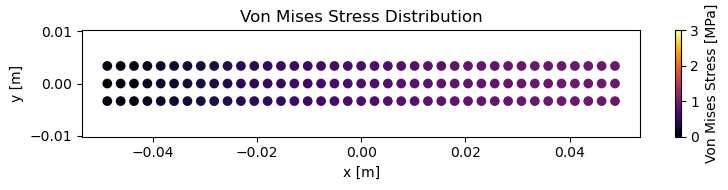


===== Specimen 23 (PLA-CNC-g-PLLA 3wt%) =====
sfepy: generating 160 vertices...
sfepy: ...done
sfepy: generating 117 cells...
sfepy: ...done


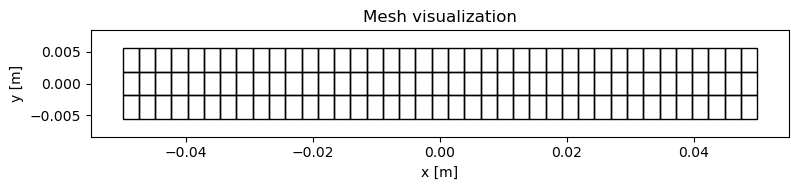

sfepy: updating variables...
sfepy: ...done
sfepy: setting up dof connectivities...
sfepy: ...done in 0.00 s
sfepy: matrix shape: (308, 308)
sfepy: assembling matrix graph...
sfepy: ...done in 0.00 s
sfepy: matrix structural nonzeros: 4530 (4.78e+00% fill)
sfepy: updating variables...
sfepy: ...done
sfepy: updating materials...
sfepy:     Mat
sfepy: ...done in 0.00 s
sfepy: nls: iter: 0, residual: 1.395293e+05 (rel: 1.000000e+00)
sfepy:   residual:    0.00 [s]
sfepy:     matrix:    0.00 [s]
sfepy:      solve:    0.00 [s]
sfepy: nls: iter: 1, residual: 1.095788e-10 (rel: 7.853459e-16)


Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to u.

sfepy: solved in 1 steps in 0.00 seconds
Max displacement magnitude: 0.001000 m


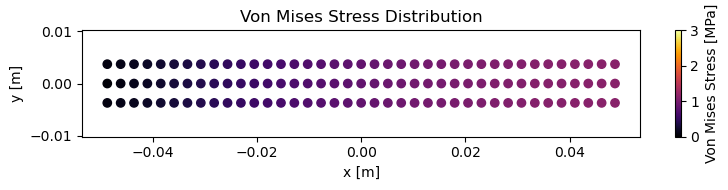

In [51]:
import sfepy
from sfepy.discrete.fem import FEDomain, Field
from sfepy.discrete import Integral, Problem
from sfepy.mechanics.matcoefs import stiffness_from_youngpoisson
from sfepy.discrete.conditions import EssentialBC
from sfepy.discrete.variables import FieldVariable
from sfepy.base.base import IndexedStruct
# from sfepy.discrete.fem.mesh import gen_block_mesh

import sfepy.mesh.mesh_generators as mg
print(dir(mg))
from sfepy.discrete.equations import Equation, Equations
from sfepy.terms import Term
from sfepy.discrete import Material
from sfepy.discrete.conditions import Conditions
from sfepy.solvers.ls import ScipyDirect
from sfepy.solvers.nls import Newton
# from sfepy.solvers.ts_solvers import StationarySolver

df2 = df[:23] # Specimen 24-33 has missing Modulus values
for idx, row in df2.iterrows():
    print(f"\n===== Specimen {idx + 1} ({row['material_type']}) =====")

    # Convert mm to meters
    width_m = row["width_mm"] / 1000.0
    thickness_m = row["thickness_mm"] / 1000.0

    # Length of specimen (arbitrary, e.g., 100 mm)
    length_m = 0.1 

    # Young's modulus in Pa
    E_pa = row["modulus_Mpa"] * 1e6
    nu = 0.3

    # Applied tensile displacement (1 mm)
    disp_value = 0.001

    # ---------------------------------------------
    # Create 2D mesh using gen_block_mesh
    # ---------------------------------------------
    dims = [length_m, width_m]
    shape = [40, 4] # elements
    mesh = mg.gen_block_mesh(
                dims=dims,
                shape=shape,
                centre=[0,0],
                name='mesh'
            )

    # Create domain and regions
    domain = FEDomain('domain', mesh)
    # Get mesh coordinates
    coors = domain.get_mesh_coors()
    xmax = coors[:,0].max()
    # print("x min:", coors[:,0].min())
    # print("x max:", coors[:,0].max())
    # print("Unique sorted x coordinates:")
    # print(np.unique(np.round(coors[:,0], decimals=8)))
    tol = 1e-8
    omega = domain.create_region('Omega', 'all') # all elements in the material
    left = domain.create_region(
        'Left', 
        # 'vertices in x < tol',
        f'vertices in (x < {-length_m/2 + tol})',
        'vertex'
        )
    right = domain.create_region(
                            'Right', 
                            # f'vertices in x > {length_m - tol}',
                            # f'vertices in (x < {coors[:,0].max()})',
                            f'vertices in (x > {xmax - tol})',
                            'vertex',
                            )

    # Create field
    field = Field.from_args('displacement', np.float64, 2, omega, approx_order=1)

    # Create variables
    u = FieldVariable('u', 'unknown', field)
    v = FieldVariable('v', 'test', field, primary_var_name='u')

    # Material stiffness matrix
    D_mat = stiffness_from_youngpoisson(2, E_pa, nu)
    # material = Material('Mat', D=D_mat)
    material = Material('Mat', values={'young': E_pa, 'poisson': nu})

    # Integral
    integral = Integral('i', order=2)

    # Define linear elasticity term
    # t1 = Term.new('dw_lin_elastic_iso(Mat.D, v, u)', integral, omega, Mat=material, v=v, u=u)
    t1 = Term.new('dw_lin_elastic_iso(Mat.young, Mat.poisson, v, u)', integral, omega, Mat=material, v=v, u=u)

    # Define equations
    eq = Equation('balance_of_forces', t1)
    equations_obj = Equations([eq])

    # Define boundary conditions
    fix_left = EssentialBC('fix_left', left, {'u.all': 0.0})
    disp_right = EssentialBC('disp_right', right, {'u.0': disp_value})

    # View the mesh directly (before solving)
    coors = domain.get_mesh_coors()
    conn = mesh.get_conn(mesh.descs[0])
    plt.figure(figsize=(8,2))
    for elem in conn:
        x = coors[elem,0]
        y = coors[elem,1]
        plt.fill(x, y, edgecolor='k', fill=False)
    plt.title("Mesh visualization")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

    # Create the main stationary solver combining them
    # stationary_solver = StationarySolver({}, ls=ScipyDirect({}), nls=Newton({}))
    solvers = {
    'ls' : ('ls.scipy_direct', {}),
    'newton' : ('nls.newton',
                {'i_max'      : 1,
                 'eps_a'      : 1e-10,}),
    }
    options = {
    'nls' : 'newton',
    'ls' : 'ls',
    }

    ls = ScipyDirect({})
    nls_status = IndexedStruct()
    nls = Newton({}, lin_solver=ls, status=nls_status)

    # Create problem with solver objects
    problem = Problem('tensile_test', equations=equations_obj) 
    problem.set_bcs(ebcs=Conditions([fix_left, disp_right]))
    # problem.set_bcs(ebcs=[fix_left, disp_right])

    # problem.set_solver('ls', ScipyDirect({}))  # pass solver instance
    problem.set_solver(nls)  # pass Newton solver instance

    # Solve
    status = IndexedStruct()
    problem.solve(status=status)

    # print('Nonlinear solver status:\n', nls_status)
    # print('Stationary solver status:\n', status)

    # Retrieve displacement field
    displacement = problem.get_variables()['u'].data 
    print("Max displacement magnitude: {:.6f} m".format(np.max(np.abs(displacement))))

    # Save solution to visualize in Paraview if you want
    # problem.save_state(f"specimen_{idx+1}_solution.vtk", out=problem.solve(status=status)) #********

    #===============================================
    # Plot displacement magnitudes (optional)
    #===============================================
    # displacement = np.array(displacement) # Convert to NumPy array
    # coors = domain.get_mesh_coors() # Retrieve coordinates of nodes
    # ux = displacement[0::2]
    # uy = displacement[1::2]
    # umag = np.sqrt(ux**2 + uy**2) # Compute magnitude

    # # Scatter plot of displacement magnitudes
    # plt.figure(figsize=(8, 2))
    # sc = plt.scatter(coors[:,0], coors[:,1], c=umag*1000, cmap='viridis')
    # plt.colorbar(sc, label='Displacement Magnitude (mm)')
    # plt.xlabel('x [m]')
    # plt.ylabel('y [m]')
    # plt.title('Displacement Magnitude Field')
    # plt.tight_layout()
    # plt.show()
    #===============================================

    # Evaluate strain tensor at quadrature points (small strain tensor)
    strain_eval = problem.evaluate('ev_cauchy_strain.2.Omega(u)', mode='qp', verbose=False)

    # Material parameters (plane strain assumed)
    E = E_pa
    lambda_ = E*nu/((1+nu)*(1-2*nu))
    mu = E/(2*(1+nu))

    # strain_eval shape: (num_cells, num_qp, 3) in Voigt notation (ε_xx, ε_yy, ε_xy)
    exx = strain_eval[:,:,0].squeeze()
    eyy = strain_eval[:,:,1].squeeze()
    exy = strain_eval[:,:,2].squeeze()

    num_cells, num_qp = exx.shape
    strain_tensor = np.zeros((num_cells, num_qp, 2, 2))
    strain_tensor[:,:,0,0] = exx
    strain_tensor[:,:,1,1] = eyy
    strain_tensor[:,:,0,1] = exy
    strain_tensor[:,:,1,0] = exy

    def compute_stress(strain_tensor):
        stress = 2 * mu * strain_tensor.copy()
        trace_strain = np.trace(strain_tensor, axis1=2, axis2=3)
        for i in range(2):
            stress[:,:,i,i] += lambda_ * trace_strain
        return stress

    stress_eval = compute_stress(strain_tensor)

    # Von Mises stress calculation (2D plane strain)
    def von_mises(stress_tensor):
        s = stress_tensor
        s_xx = s[:,:,0,0]
        s_yy = s[:,:,1,1]
        s_xy = s[:,:,0,1]
        return np.sqrt(s_xx**2 - s_xx*s_yy + s_yy**2 + 3*(s_xy**2))

    vm_stress = von_mises(stress_eval)  # shape (num_cells, num_qp)

    # Average von Mises stress per element (cell)
    vm_stress_avg = vm_stress.mean(axis=1)

    # Get element (cell) centers to plot stress
    conn = domain.mesh.get_conn(domain.mesh.descs[0])  # element connectivity
    coors = domain.get_mesh_coors()
    cell_centers = coors[conn].mean(axis=1)

    # Plot von Mises stress (in MPa)
    plt.figure(figsize=(8, 2))
    sc = plt.scatter(cell_centers[:,0], 
                     cell_centers[:,1], 
                     c=vm_stress_avg / 1e6, 
                     cmap='inferno',
                     vmin=0, 
                     vmax=3)
    plt.colorbar(sc, label='Von Mises Stress [MPa]')
    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    plt.title('Von Mises Stress Distribution')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
